In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

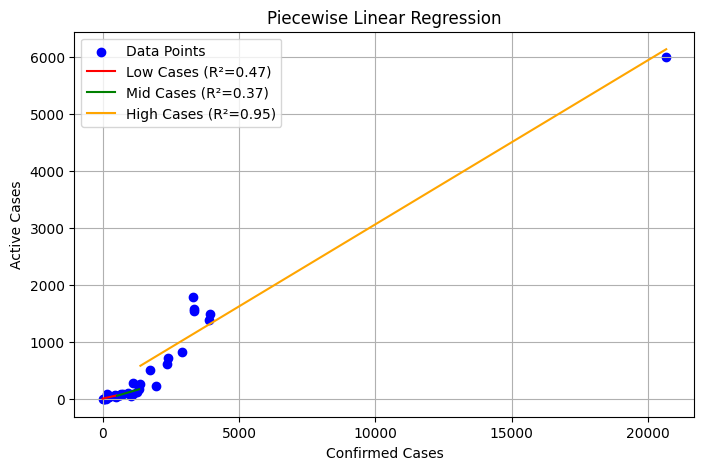

Segment Low Cases: Slope=0.109, Intercept=10.756, R²=0.466
Segment Mid Cases: Slope=0.141, Intercept=-14.267, R²=0.372
Segment High Cases: Slope=0.288, Intercept=187.503, R²=0.949


In [6]:

data = pd.read_csv('COVID-19 latest cases - Assam.csv')

numeric_columns = ["Confirmed", "Active", "Recovered", "Deceased"]
data[numeric_columns] = data[numeric_columns].replace("-", pd.NA).apply(pd.to_numeric)
data = data.fillna(0)

data_sorted = data.sort_values(by="Confirmed")

breakpoints = np.percentile(data_sorted["Confirmed"], [33, 66])


data_low = data_sorted[data_sorted["Confirmed"] <= breakpoints[0]]
data_mid = data_sorted[(data_sorted["Confirmed"] > breakpoints[0]) & (data_sorted["Confirmed"] <= breakpoints[1])]
data_high = data_sorted[data_sorted["Confirmed"] > breakpoints[1]]

# Performing piecewise linear regression
segments = [data_low, data_mid, data_high]
models = []
r2_scores = []

for segment in segments:
    X = segment["Confirmed"].values.reshape(-1, 1)
    y = segment["Active"].values.reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    
    r2_score = model.score(X, y)  # R² value
    
    models.append(model)
    r2_scores.append(r2_score)


plt.figure(figsize=(8, 5))
plt.scatter(data_sorted["Confirmed"], data_sorted["Active"], color="blue", label="Data Points")


colors = ["red", "green", "orange"]
labels = ["Low Cases", "Mid Cases", "High Cases"]

for i, segment in enumerate(segments):
    X_vals = segment["Confirmed"].values.reshape(-1, 1)
    y_vals = models[i].predict(X_vals)  # Predictions from the trained model
    
    plt.plot(X_vals, y_vals, color=colors[i], label=f"{labels[i]} (R²={r2_scores[i]:.2f})")


plt.xlabel("Confirmed Cases")
plt.ylabel("Active Cases")
plt.title("Piecewise Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

for i, model in enumerate(models):
    print(f"Segment {labels[i]}: Slope={model.coef_[0][0]:.3f}, Intercept={model.intercept_[0]:.3f}, R²={r2_scores[i]:.3f}")